# Multi-asset forecasting with an LSTM

This notebook contains code for training and forecasting 22 stocks from the OMXS30 index
with an LSTM model.

Import data and create the dataloader

In [392]:
import pandas as pd
import deeplay
import importlib
import data.MultiAssetDataset_v3
importlib.reload(data.MultiAssetDataset_v3)
from data.MultiAssetDataset_v3 import MultiAssetSequencedDataset
from torch.utils.data import DataLoader

df = pd.read_csv("data/OMXS22_model_features_raw.csv", index_col = "Date", parse_dates = True)
# Take out kinnevik and nibe

tickers = df["Ticker"].unique().tolist()
# tickers = ["KINV-B.ST"] #, "SAND.ST"]
ticker_embedding = {ticker: i for i, ticker in enumerate(tickers)}
df["Ticker embedding"] = df["Ticker"].map(ticker_embedding)
print(df.head())
features = ["Close"] #, "Ticker embedding" # , "Volume", "SMA20", "RSI14"]
target_col = "Close"
window   = 100
window_step_length = 6
horizon  = [i for i in range(1, 11)]


train_stop = pd.Timestamp("2016-01-01")
#val_stop   = pd.Timestamp("2023-07-28")
val_stop = pd.Timestamp("2019-12-13")

df_train = df[df.index < train_stop].copy()

df_val   = df[(df.index >= train_stop) & (df.index < val_stop)].copy()
df_test  = df[df.index >= val_stop].copy()
df_val_test = df[df.index >= train_stop].copy()


ds_train = MultiAssetSequencedDataset(df_train, tickers, features, target_col, False, window, window_step_length=50, horizon=horizon, num_permutations=75)
ds_train.create()
ds_val   = MultiAssetSequencedDataset(df_val,   tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_val.create()
ds_test  = MultiAssetSequencedDataset(df_test,  tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_test.create()
ds_val_test = MultiAssetSequencedDataset(df_val_test,  tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_val_test.create()


train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
val_loader   = DataLoader(ds_val,   batch_size=32)
test_loader  = DataLoader(ds_test,  batch_size=32)

print(f"Train set length: {len(ds_train)}")
print(f"Train set input shape: {ds_train[0][0].shape}")
print(f"Train set target shape: {ds_train[0][1].shape}")
print(f"Val set length: {len(ds_val)}")
print(f"Dataset length: {len(ds_train) + len(ds_val) + len(ds_test)}")

print(f"Test set number of days: {len(df_test.index.unique())}")
print(f"Test set number of sequences: {len(ds_test)}")

print(f"first day of test set trading: {ds_test.sequence_dates[0]}")

               Ticker       Close  ...  BRENT_ret  Ticker embedding
Date                               ...                             
2000-01-04  ASSA-B.ST   23.572845  ...   0.017296                 0
2000-01-04  ATCO-A.ST    3.945862  ...   0.017296                 1
2000-01-04  ATCO-B.ST    3.067595  ...   0.017296                 2
2000-01-04     AZN.ST  279.147308  ...   0.017296                 3
2000-01-04  ELUX-B.ST   31.041374  ...   0.017296                 4

[5 rows x 14 columns]
Train set length: 6000
Train set input shape: torch.Size([100, 22])
Train set target shape: torch.Size([220])
Val set length: 89
Dataset length: 6213
Test set number of days: 1349
Test set number of sequences: 124
first day of test set trading: 2020-05-13 00:00:00


In [393]:
print(ds_val.y_mean.mean(), ds_test.y_mean.mean())

110.8299012521923 190.04832161943932


In [394]:
sequence_dates = ds_test.sequence_dates.copy()
target_dates = ds_test.target_dates.copy()
print(f"Test set sequence dates: {sequence_dates}")
print(f"Test set target dates: {target_dates}")
print(f"len(sequence_dates): {len(sequence_dates)}")

Test set sequence dates: [Timestamp('2020-05-13 00:00:00'), Timestamp('2020-05-28 00:00:00'), Timestamp('2020-06-11 00:00:00'), Timestamp('2020-06-26 00:00:00'), Timestamp('2020-07-10 00:00:00'), Timestamp('2020-07-24 00:00:00'), Timestamp('2020-08-07 00:00:00'), Timestamp('2020-08-21 00:00:00'), Timestamp('2020-09-04 00:00:00'), Timestamp('2020-09-18 00:00:00'), Timestamp('2020-10-02 00:00:00'), Timestamp('2020-10-16 00:00:00'), Timestamp('2020-10-30 00:00:00'), Timestamp('2020-11-13 00:00:00'), Timestamp('2020-11-27 00:00:00'), Timestamp('2020-12-11 00:00:00'), Timestamp('2020-12-29 00:00:00'), Timestamp('2021-01-15 00:00:00'), Timestamp('2021-01-29 00:00:00'), Timestamp('2021-02-12 00:00:00'), Timestamp('2021-02-26 00:00:00'), Timestamp('2021-03-12 00:00:00'), Timestamp('2021-03-26 00:00:00'), Timestamp('2021-04-13 00:00:00'), Timestamp('2021-04-27 00:00:00'), Timestamp('2021-05-11 00:00:00'), Timestamp('2021-05-26 00:00:00'), Timestamp('2021-06-09 00:00:00'), Timestamp('2021-06-23 

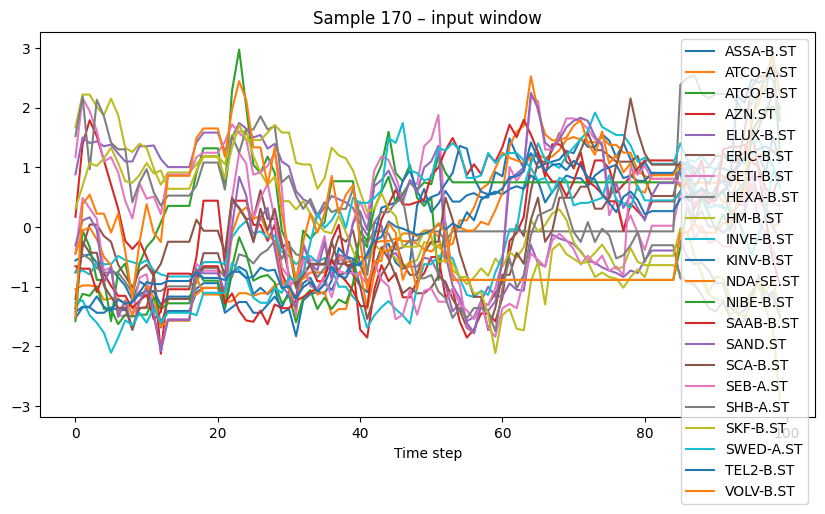

In [395]:
import matplotlib.pyplot as plt

def plot_sample_from_dataset(ds, idx=0, tickers=None, features=None):
    """
    Visualiserar en sample från ett MultiAssetSequencedDataset.

    Parametrar:
        ds       – dataset-instans (t.ex. ds_train)
        idx      – vilket sample (default: 0)
        tickers  – lista med ticker-namn (om du vill annotera)
        features – lista med feature-namn (för att tolka A*F)
    """
    x, y = ds[idx]  # x: (W, A*F), y: (A,) eller (A, H)

    W = x.shape[0]
    AF = x.shape[1]
    A = len(ds.tickers)
    F = len(ds.features)

    # Återskapa till (W, A, F)
    x = x.view(W, A, F).numpy()
    if F > 1:
        fig, axs = plt.subplots(F, 1, figsize=(10, 2.5 * F), sharex=True)

        for f in range(F):
            ax = axs[f] if F > 1 else axs
            for a in range(A):
                label = tickers[a] if tickers else f"Asset {a}"
                ax.plot(range(W), x[:, a, f], label=label)
            feat_name = features[f] if features else f"Feature {f}"
            ax.set_title(f"Feature {f}: {feat_name}")
            ax.legend()
        
        plt.suptitle(f"Sample {idx} – input window")
        plt.xlabel("Time step")
        #plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(10, 5))
        for a in range(A):
            label = tickers[a] if tickers else f"Asset {a}"
            plt.plot(range(W), x[:, a, 0], label=label)
        plt.title(f"Sample {idx} – input window")
        plt.xlabel("Time step")
        plt.legend()
        plt.show()

plot_sample_from_dataset(ds_train, idx=170, tickers=tickers, features=features)


In [397]:
import torch
import torch.nn as nn
import torch.optim as optim
from multi_asset_models.MultiAssetLSTM import MultiAssetLSTM
from train.Trainer import Trainer

model = MultiAssetLSTM(
    n_assets=len(tickers),
    n_features=len(features),
    hidden_size=132,
    num_layers=4,
    dropout=0.2,
    horizon=horizon
)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


num_epochs   = 15
patience     = num_epochs
save_path    = "best_multiasset_lstm.pt"

trainer = Trainer(model, optimizer, criterion)
history = trainer.fit(
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = num_epochs,
    patience     = patience,
    save_path    = save_path
)

model.load_state_dict(torch.load(save_path))
test_loss = trainer.eval_epoch(test_loader)
print(f"Test loss: {test_loss:.4f}")

Epoch 1/15 - train_loss: 0.9156, val_loss: 0.8254
Epoch 2/15 - train_loss: 0.6899, val_loss: 0.6842
Epoch 3/15 - train_loss: 0.6447, val_loss: 0.6622
Epoch 4/15 - train_loss: 0.6267, val_loss: 0.6553
Epoch 5/15 - train_loss: 0.6163, val_loss: 0.6426
Epoch 6/15 - train_loss: 0.6091, val_loss: 0.6338
Epoch 7/15 - train_loss: 0.6034, val_loss: 0.6304
Epoch 8/15 - train_loss: 0.5982, val_loss: 0.6120
Epoch 9/15 - train_loss: 0.5912, val_loss: 0.6266
Epoch 10/15 - train_loss: 0.5810, val_loss: 0.6290
Epoch 11/15 - train_loss: 0.5716, val_loss: 0.6122
Epoch 12/15 - train_loss: 0.5619, val_loss: 0.6186
Epoch 13/15 - train_loss: 0.5561, val_loss: 0.6108
Epoch 14/15 - train_loss: 0.5502, val_loss: 0.6169
Epoch 15/15 - train_loss: 0.5455, val_loss: 0.6126
Test loss: 0.6249


Naive MAE: 1.7102


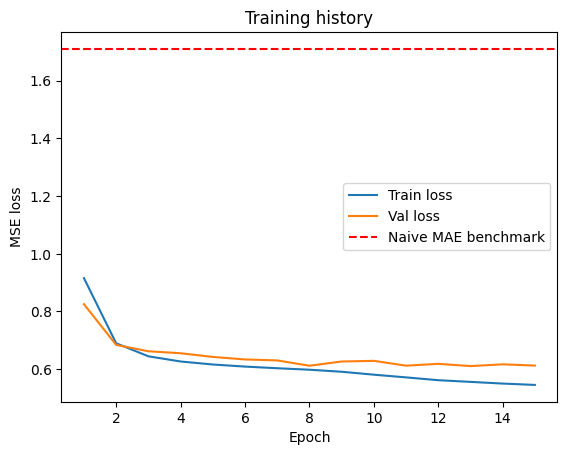

In [398]:
import numpy as np
import matplotlib.pyplot as plt

ys = []
for _, y in DataLoader(ds_test, batch_size=128):
    ys.append(y)
ys = torch.cat(ys, dim=0).numpy()
if ys.ndim == 3:
    ys = ys[:, :, 0]

naive_errors = np.abs(ys[max(horizon):] - ys[:-max(horizon)])
naive_mae = naive_errors.mean()

print(f"Naive MAE: {naive_mae:.4f}")

epochs = np.arange(1, len(history['train_loss']) + 1)
plt.figure()
plt.plot(epochs, history['train_loss'], label='Train loss')
if 'val_loss' in history:
    plt.plot(epochs, history['val_loss'], label='Val loss')
plt.axhline(y=naive_mae, color='r', linestyle='--', label='Naive MAE benchmark')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training history')
plt.legend()
plt.show()

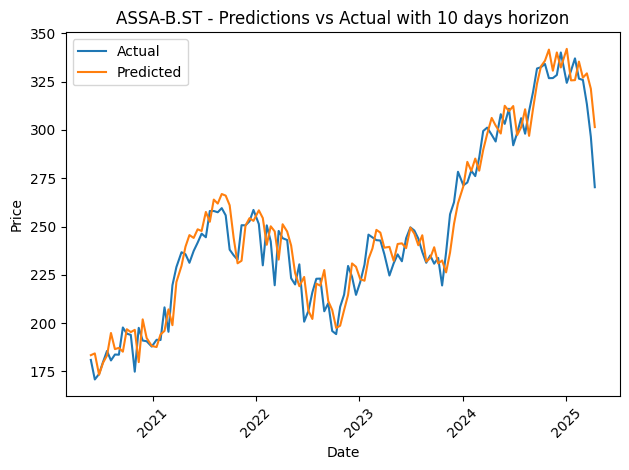

Accuracy: 0.0352
Total accuracy on last horizon: 0.0488
ASSA-B.ST: 0.0356
ATCO-A.ST: 0.0452
ATCO-B.ST: 0.0458
AZN.ST: 0.0409
ELUX-B.ST: 0.0627
ERIC-B.ST: 0.0483
GETI-B.ST: 0.0638
HEXA-B.ST: 0.0532
HM-B.ST: 0.0596
INVE-B.ST: 0.0339
KINV-B.ST: 0.0760
NDA-SE.ST: 0.0348
NIBE-B.ST: 0.0763
SAAB-B.ST: 0.0581
SAND.ST: 0.0498
SCA-B.ST: 0.0425
SEB-A.ST: 0.0370
SHB-A.ST: 0.0413
SKF-B.ST: 0.0497
SWED-A.ST: 0.0424
TEL2-B.ST: 0.0328
VOLV-B.ST: 0.0441
Stock accuracy: 0.0356


In [399]:
import importlib
import functions.plot_predictions
importlib.reload(functions.plot_predictions)
from functions.plot_predictions import plot_predictions

model.load_state_dict(torch.load(save_path))
model.eval()
idx = 0
plot_predictions(
    idx,
    tickers,
    test_loader.dataset,
    model,
    0,
    20000
)
# for idx in range(0, len(tickers)):
#     plot_predictions(
#         idx,
#         tickers,
#         test_loader,
#         model,
#         0,
#         20000
#     )

In [432]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=1.0
)

X, y = ds_test[8]
X = X.unsqueeze(0)
y = y.unsqueeze(0)
preds = model(X)
preds = preds.view(1, len(tickers), max(horizon))
X = X.unsqueeze(-1)

weights = weight_optimizer(X, preds)
print(np.max(weights.numpy()))
for i, ticker in enumerate(tickers):
    print(f"{ticker}: {weights[0, i].item():.4f}")

[Warning] Optimization failed at sample 0. Using equal weights.
0.045454547
ASSA-B.ST: 0.0455
ATCO-A.ST: 0.0455
ATCO-B.ST: 0.0455
AZN.ST: 0.0455
ELUX-B.ST: 0.0455
ERIC-B.ST: 0.0455
GETI-B.ST: 0.0455
HEXA-B.ST: 0.0455
HM-B.ST: 0.0455
INVE-B.ST: 0.0455
KINV-B.ST: 0.0455
NDA-SE.ST: 0.0455
NIBE-B.ST: 0.0455
SAAB-B.ST: 0.0455
SAND.ST: 0.0455
SCA-B.ST: 0.0455
SEB-A.ST: 0.0455
SHB-A.ST: 0.0455
SKF-B.ST: 0.0455
SWED-A.ST: 0.0455
TEL2-B.ST: 0.0455
VOLV-B.ST: 0.0455


c:\Users\peogr\OneDrive - Chalmers\GitHub\Project-AMLNN\portfolio_optimizers\portfolio_optimizer.py:75: RuntimeWarning: invalid value encountered in log
  log_risk = np.log(1 + w @ past_returns.T)


               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [1.0010273  1.01313635 1.00062361 0.98387264 0.99376177 0.98104715
 0.98407445 0.97519443 0.95783783 0.93422482]
Weights: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Full horizon predictions: tensor([148.2798,  33.5740,  29.2937, 465.8347, 133.6188,  52.2866, 109.4134,
         44.9600, 179.5927,  60.2214, 100.3286,  77.5589,  16.7917,  60.9575,
         66.9410,  44.2215,  54.9391,  71.9534, 112.0590, 101.0444,  41.7100,
         66.4285])
Last know prices: tensor([146.9625,  32.6382,  28.9454, 463.9162, 132.5318,  51.6390, 106.7377,
         44.5239, 178.1694,  60.1472,  98.6538,  76.7828,  16.8409,  59.4005,
         65.9598,  43.7296,  54.9632,  72.7297, 110.7166, 101.9539,  41.2655,
         65.2522])
first horizon target: tensor([147.0486,  32.6686,  28.9600, 465.3234, 132.0665,  51.4394, 105.405

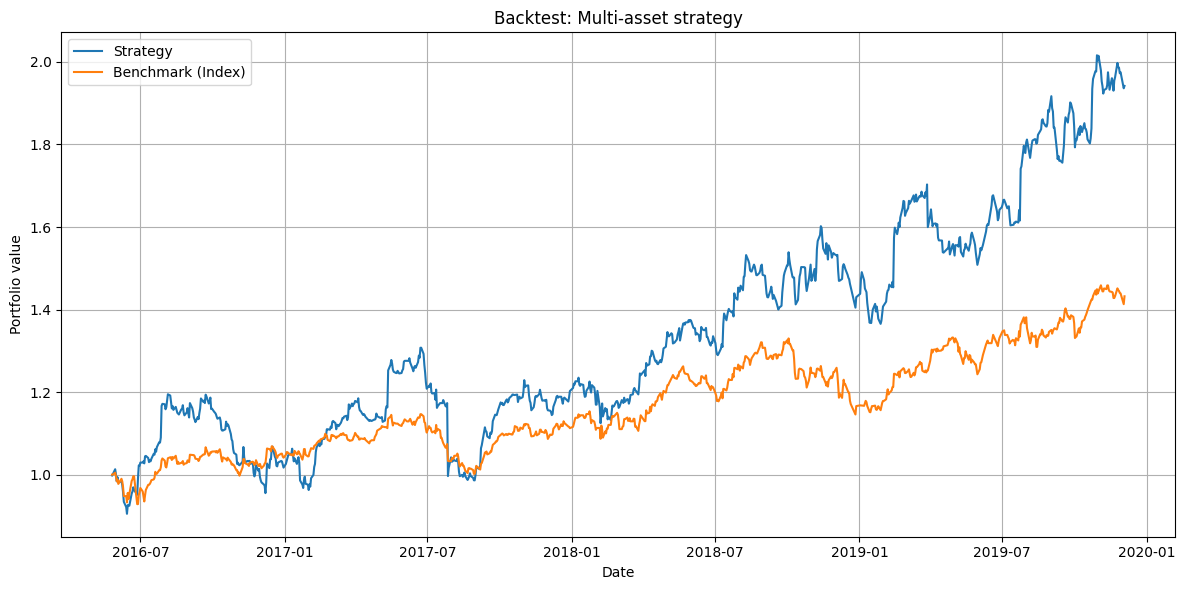

[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.

In [433]:
# Backtest
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_val.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="softmax_pred",
    multi_horizon=True,
    risk_aversion=1.0
)

result = backtest_multi_asset(
    ds_val,
    model,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.002,
)

print(result["weights"])
print(f"Mean weights: {np.array(result['weights']).mean(axis=0)}")
# print(result["values"][-1])
# print(result["benchmark"][-1])
# print(result["values"][-1] / result["benchmark"][-1])
# print(result["dates"][-1])
# print(result["benchmark"][-1], result["benchmark"][0])

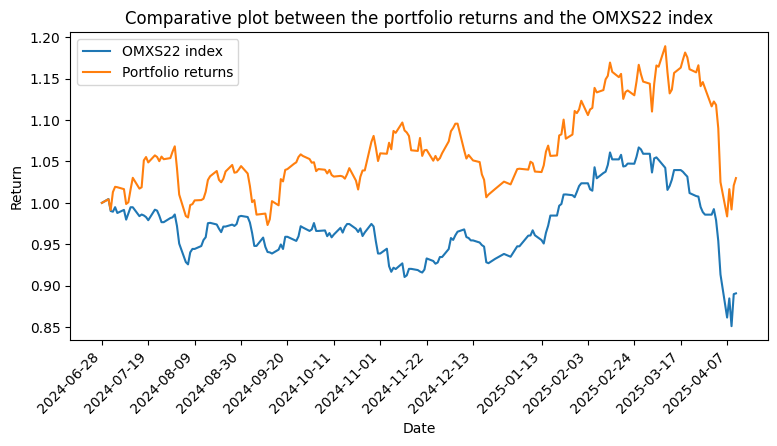

Last portfolio value: 1.0299


In [414]:
portfolio_dates = result["dates"]
portfolio_vals = result["values"]
index_vals = result["benchmark"]


plt.figure(figsize=(9, 4))
if index_vals is not None:
    plt.plot(portfolio_dates[-200:], np.array(index_vals[-200:])/index_vals[-200], label="OMXS22 index")
plt.plot(portfolio_dates[-200:], np.array(portfolio_vals[-200:])/portfolio_vals[-200], label="Portfolio returns")
plt.xlabel("Date")
plt.xticks(
        portfolio_dates[-200::15], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.ylabel("Return")
plt.title("Comparative plot between the portfolio returns and the OMXS22 index")
plt.legend()
plt.show()
print(f"Last portfolio value: {(np.array(portfolio_vals[-200:])/portfolio_vals[-200])[-1]:.4f}")

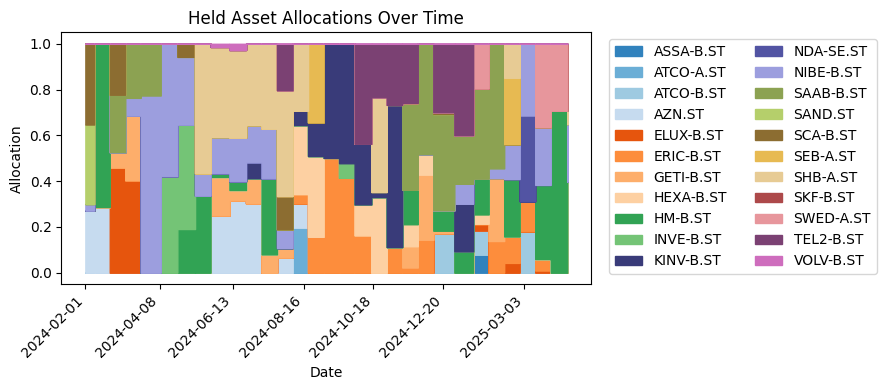

(22, 1241)


In [413]:
def plot_allocations(alloc, tickers, dates):
    n_assets, T = alloc.shape
    # Stack allocations
    cumsum = np.cumsum(alloc, axis=0)
    base_cmap = plt.get_cmap('tab20c')
    extra_cmap = plt.get_cmap('tab20b')
    colors = []
    for i in range(n_assets):
        if i < 10:
            colors.append(base_cmap(i))  # tab20 has 20 distinct
        else:
            # pick from hsv evenly for any extras
            colors.append(extra_cmap((i-10) / max(1, n_assets-10)))

    #cmap = plt.get_cmap('tab20', n_assets)
    #colors = [cmap(i) for i in range(n_assets)]

    plt.figure(figsize=(9,4))
    for i, ticker in enumerate(tickers):
        bottom = cumsum[i-1] if i>0 else np.zeros(T)
        top    = cumsum[i]
        # use dates on the x-axis
        plt.fill_between(dates, bottom, top, step='post', label=ticker, color=colors[i])

    # now the ticks are the dates themselves
    plt.xticks(
        dates[::45], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )

    plt.xlabel('Date')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

weights = np.array(result["weights"])  # shape: (num_rebalances, num_assets)
dates = np.array(result["dates"])      # dagliga datum (len = N)

allocations_filled = np.zeros((len(tickers), len(dates)))

rebalance_idxs = np.linspace(0, len(dates)-1, len(weights), dtype=int)
for i in range(len(rebalance_idxs)):
    start = rebalance_idxs[i]
    end = rebalance_idxs[i+1] if i+1 < len(rebalance_idxs) else len(dates)
    allocations_filled[:, start:end] = np.expand_dims(weights[i], axis=1)

plot_allocations(allocations_filled[:, -300:], tickers, dates[-300:])
print(allocations_filled.shape)

In [10]:
import deeplay as dl


gru_dl = dl.RecurrentModel(
    in_features=len(features)*len(tickers),
    hidden_features=[128, 128, 128],
    out_features=len(tickers)*len(horizon),
    rnn_type="GRU",
    dropout=0.2,
)
gru_stacked = dl.Regressor(gru_dl, optimizer=dl.Adam(lr=0.001)).create()

trainer = dl.Trainer(max_epochs=1, accelerator="auto")
trainer.fit(gru_stacked, train_loader, val_loader)

train_losses = trainer.history.history["train_loss_epoch"]["value"]
val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]


  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | RecurrentModel   | 313 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
313 K     Trainable params
0         Non-trainable params
313 K     Total params
1.253     Total estimated model params size (MB)
23        Modules in train mode
1         Modules in eval mode


C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 141/141 [00:25<00:00,  5.52it/s, v_num=35, train_loss_step=0.467, val_loss_step=0.793, val_loss_epoch=0.528, train_loss_epoch=0.391]


ValueError: x and y must have same first dimension, but have shapes (50,) and (1,)

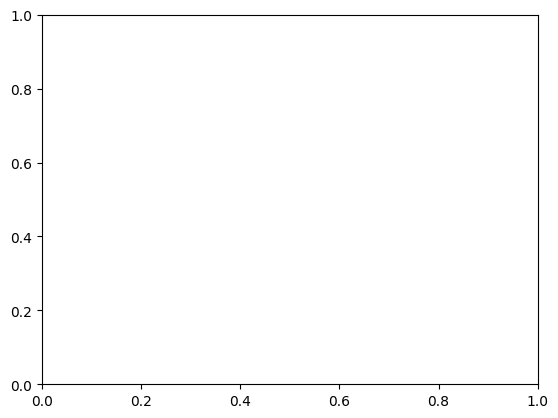

In [11]:
def plot_training(epochs, train_losses, val_losses, benchmark):
    """Plot the training and validation losses."""
    plt.plot(range(epochs), train_losses, label="Training Loss")
    plt.plot(range(epochs), val_losses, "--", label="Validation Loss")
    plt.plot([0, epochs - 1], [benchmark, benchmark], ":k", label="Benchmark")
    plt.xlabel("Epoch")
    plt.xlim([0, epochs - 1])
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_training(50, train_losses, val_losses, benchmark = naive_mae)

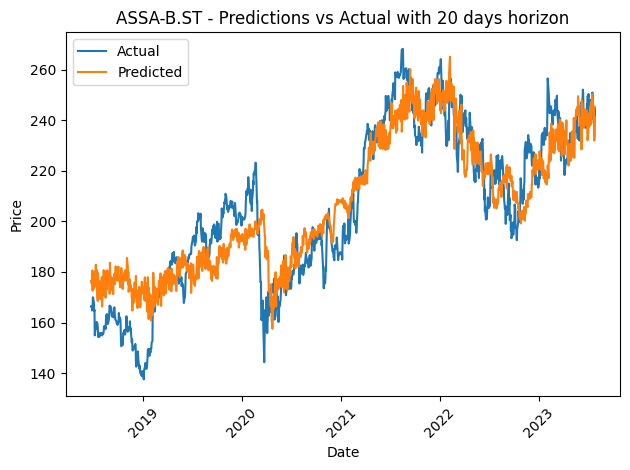

Accuracy: 0.1337
Total accuracy on last horizon: 0.1398
ASSA-B.ST: 0.0572
ATCO-A.ST: 0.1420
ATCO-B.ST: 0.1273
AZN.ST: 0.1662
ELUX-B.ST: 0.1329
ERIC-B.ST: 0.1755
GETI-B.ST: 0.1743
HEXA-B.ST: 0.0901
HM-B.ST: 0.1410
INVE-B.ST: 0.1091
KINV-B.ST: 0.2335
NDA-SE.ST: 0.1256
NIBE-B.ST: 0.2619
SAAB-B.ST: 0.3333
SAND.ST: 0.0753
SCA-B.ST: 0.1330
SEB-A.ST: 0.1008
SHB-A.ST: 0.0828
SKF-B.ST: 0.0879
SWED-A.ST: 0.1362
TEL2-B.ST: 0.0923
VOLV-B.ST: 0.0978
Stock accuracy: 0.0572


In [12]:
# Plot predictions vs actual on test set
import torch
import numpy as np
import matplotlib.pyplot as plt
from functions.plot_predictions import plot_predictions


plot_predictions(
    idx,
    tickers,
    val_loader,
    gru_stacked,
    0,
    20000
)


In [276]:
import deeplay as dl

class CrossAttentionGRUV2(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_hidden_layers, out_dim, dropout, num_heads):
        super().__init__()
        self.gru_model = nn.GRU(in_dim, hidden_dim, num_layers=num_hidden_layers, dropout=dropout, batch_first=True)
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, kdim=in_dim, vdim=in_dim, dropout=0, batch_first=True)
        self.fuse_fc = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU()
        )
        self.fc = nn.Linear(hidden_dim, out_dim)
        self._stored_attn_weights = None

    def get_attn_weights(self):
        return self._stored_attn_weights

    def forward(self, x):
        gru_out, _ = self.gru_model(x)

        x_proj = x #self.input_proj(x)

        cross_attn_out, cross_attn_weights = self.cross_attn(query=gru_out, key=x_proj, value=x_proj)

        self._stored_attn_weights = cross_attn_weights.detach()
        #print('gru:', gru_out)
        #print('cross attn: ', cross_attn_out)

        combined = torch.cat([gru_out, cross_attn_out], dim=-1)
        fused = self.fuse_fc(combined)
        #print(combined.shape)

        final_step = fused[:, -1, :]
        #print(final_step.shape)

        output = self.fc(final_step)

        return output

In [277]:
cross_attention_gru_model = CrossAttentionGRUV2(in_dim=len(tickers)*len(features), hidden_dim=144, num_hidden_layers=2, out_dim=len(tickers)*len(horizon), dropout=0.2, num_heads=24)

cross_attention_gru_reg = dl.Regressor(cross_attention_gru_model, optimizer=dl.Adam(lr=0.001)).create()

trainer_cross_gru = dl.Trainer(max_epochs=20, accelerator="auto")
trainer_cross_gru.fit(cross_attention_gru_reg, train_loader, val_loader)

train_losses = trainer_cross_gru.history.history["train_loss_epoch"]["value"]
val_losses = trainer_cross_gru.history.history["val_loss_epoch"]["value"][1:]


  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV2 | 323 K  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
323 K     Trainable params
0         Non-trainable params
323 K     Total params
1.292     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 19: 100%|██████████| 141/141 [00:26<00:00,  5.34it/s, v_num=45, train_loss_step=0.474, val_loss_step=0.647, val_loss_epoch=0.655, train_loss_epoch=0.470]


In [253]:
plot_training(50, train_losses, val_losses, naive_mae)

NameError: name 'plot_training' is not defined

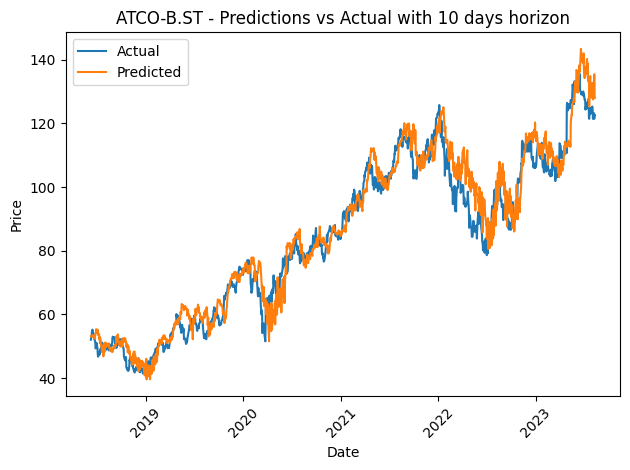

Accuracy: 0.0410
Total accuracy on last horizon: 0.0552
ASSA-B.ST: 0.0418
ATCO-A.ST: 0.0527
ATCO-B.ST: 0.0542
AZN.ST: 0.0399
ELUX-B.ST: 0.0684
ERIC-B.ST: 0.0537
GETI-B.ST: 0.0650
HEXA-B.ST: 0.0546
HM-B.ST: 0.0710
INVE-B.ST: 0.0377
KINV-B.ST: 0.0732
NDA-SE.ST: 0.0542
NIBE-B.ST: 0.0659
SAAB-B.ST: 0.0760
SAND.ST: 0.0567
SCA-B.ST: 0.0548
SEB-A.ST: 0.0467
SHB-A.ST: 0.0443
SKF-B.ST: 0.0578
SWED-A.ST: 0.0519
TEL2-B.ST: 0.0421
VOLV-B.ST: 0.0522
Stock accuracy: 0.0542


In [278]:
# Plot predictions vs actual on test set
import torch
import numpy as np
import matplotlib.pyplot as plt
idx = 2

plot_predictions(
    idx,
    tickers,
    val_loader.dataset,
    cross_attention_gru_reg,
    0,
    2000
)

Scaled returns: [0.98200955 0.98968504 0.99235171 0.99352778 0.97025602 0.94947871
 0.94673893 0.94746888 0.93151322 0.91460595]
Weights: [0.00000000e+00 3.93260490e-17 0.00000000e+00 0.00000000e+00
 1.75899279e-17 1.26945258e-18 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.35358428e-17 0.00000000e+00 0.00000000e+00
 4.50239211e-01 0.00000000e+00 0.00000000e+00 3.97229850e-01
 0.00000000e+00 1.35250085e-17 0.00000000e+00 5.61092946e-18
 1.52530968e-01 1.48725966e-17]
Full horizon predictions: tensor([ 287.6255,  172.2492,  147.3466, 1399.3345,  108.7607,   60.4967,
         229.6728,  123.8099,  172.2678,  232.8877,  110.0831,  125.0035,
          72.3445,  154.4088,  210.1533,  148.6290,  132.0920,   98.9479,
         188.7726,  176.2112,   85.5613,  251.4036])
Last know prices: tensor([ 280.5746,  166.7444,  142.9289, 1386.2701,  108.5500,   60.1531,
         222.6485,  119.1435,  165.1971,  227.1922,  107.6500,  125.2761,
          69.1390,  152.8889,  207.0451,  146.8299,  130.1

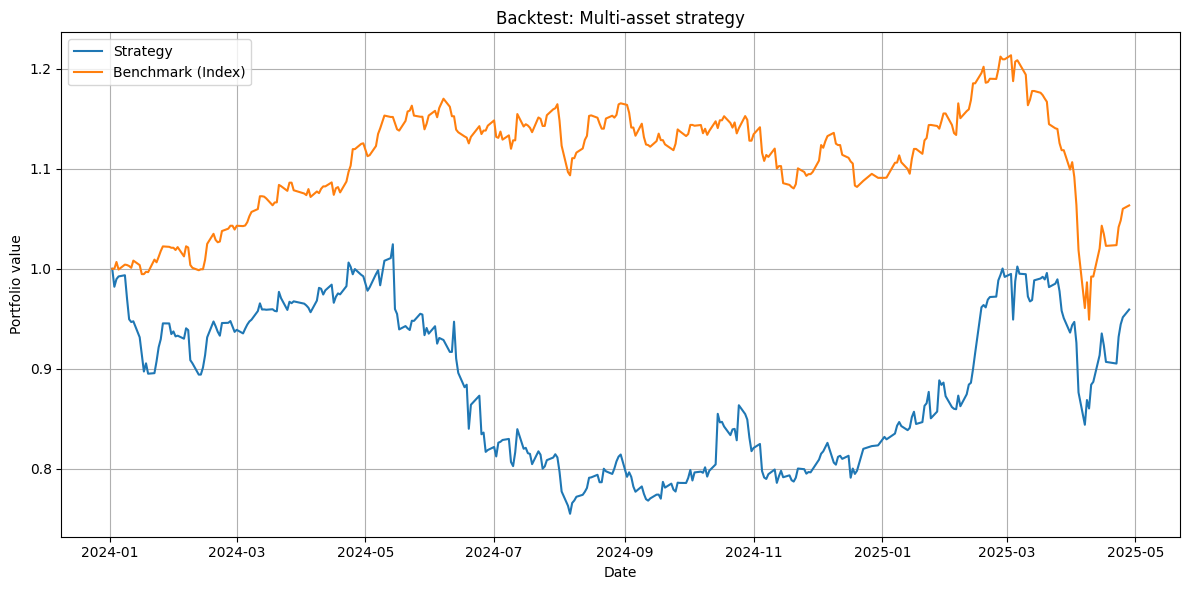

Scaled returns: [0.99663638 0.98703774 0.98072549 0.97187779 0.98593446 0.98773373
 0.98534951 0.98534951 0.97761598 0.9765783 ]
Weights: [2.56013938e-17 0.00000000e+00 0.00000000e+00 2.27370411e-17
 3.59511077e-01 1.48608357e-01 0.00000000e+00 7.47443736e-02
 0.00000000e+00 4.90698925e-18 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.19436766e-17 1.84726700e-01 0.00000000e+00
 2.32409507e-01 3.19241325e-17 4.54812852e-18 0.00000000e+00
 2.09319328e-17 1.16156579e-18]
Full horizon predictions: tensor([169.4104,  60.2988,  53.1732, 604.8844, 142.1825,  54.8440,  77.3421,
         68.9277, 105.9628,  80.9916, 154.6113,  83.9154,  21.6640,  79.4701,
        132.7569,  90.6532,  65.8832,  70.0107, 141.1213, 119.1279,  67.4298,
        117.0887])
Last know prices: tensor([170.1894,  59.7715,  52.6720, 636.2538, 138.1184,  54.0448,  75.5016,
         67.9118, 104.9022,  80.3905, 154.2000,  82.7769,  21.9520,  79.0990,
        130.6075,  90.7103,  63.7872,  69.9895, 142.5505, 117.1554,  69.

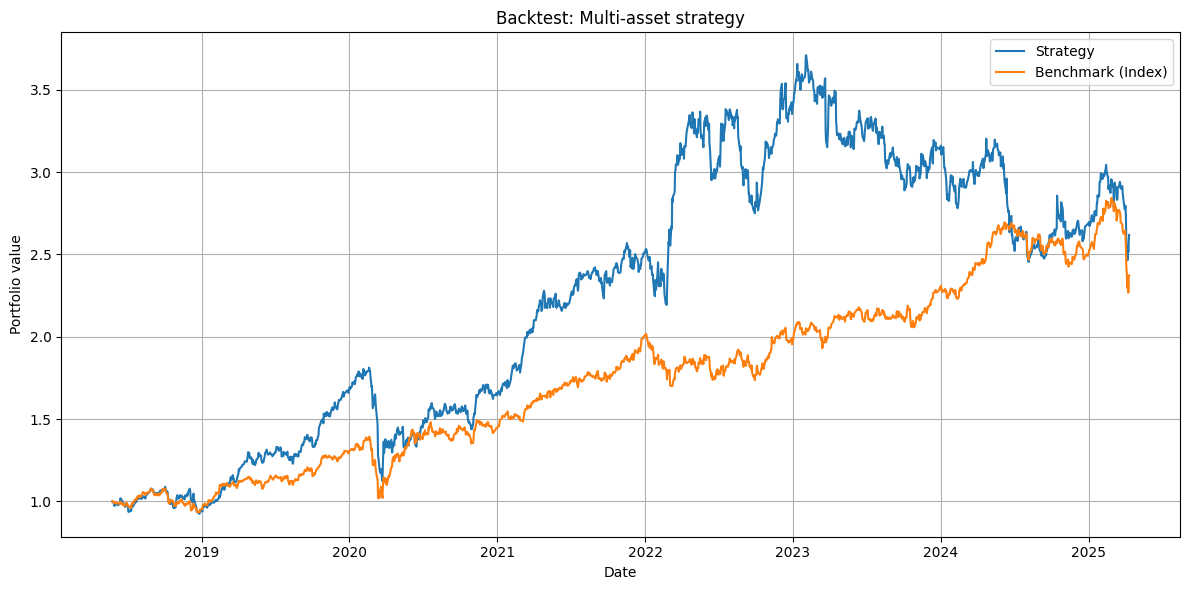

In [281]:
# backtest
weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=1.5
)
result = backtest_multi_asset(
    ds_test,
    cross_attention_gru_reg,
    weight_optimizer,
    df_test,
    index_df=df_index,
    plot=True
)
result = backtest_multi_asset(
    ds_val_test,
    cross_attention_gru_reg,
    weight_optimizer,
    df_val_test,
    index_df=df_index,
    plot=True
)

In [263]:
import torch.nn as nn

class CrossAttentionLSTMV1(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_hidden_layers, out_dim, dropout, num_heads):
        super().__init__()
        self.gru_model = nn.LSTM(in_dim, hidden_dim, num_layers=num_hidden_layers, dropout=dropout, batch_first=True)
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, kdim=hidden_dim, vdim=hidden_dim, dropout=0, batch_first=True)
        self.fuse_fc = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU()
        )
        self.fc = nn.Linear(hidden_dim, out_dim)
        self._stored_attn_weights = None

    def get_attn_weights(self):
        return self._stored_attn_weights

    def forward(self, x):
        gru_out, _ = self.gru_model(x)

        x_proj = self.input_proj(x)

        cross_attn_out, cross_attn_weights = self.cross_attn(query=gru_out, key=x_proj, value=x_proj)

        self._stored_attn_weights = cross_attn_weights.detach()
        #print('gru:', gru_out)
        #print('cross attn: ', cross_attn_out)

        combined = cross_attn_out+gru_out
        #fused = self.fuse_fc(combined)
        #print(combined.shape)

        final_step = combined[:, -1, :]
        #print(final_step.shape)

        output = self.fc(final_step)

        return output

In [264]:
cross_attention_lstm_model = CrossAttentionLSTMV1(in_dim=len(tickers)*len(features), hidden_dim=144, num_hidden_layers=2, out_dim=len(tickers)*len(horizon), dropout=0.2, num_heads=24)

cross_attention_lstm_reg = dl.Regressor(cross_attention_lstm_model, optimizer=dl.Adam(lr=0.001)).create()

trainer_cross_lstm = dl.Trainer(max_epochs=50, accelerator="auto")
trainer_cross_lstm.fit(cross_attention_lstm_reg, train_loader, val_loader)

train_losses = trainer_cross_lstm.history.history["train_loss_epoch"]["value"]
val_losses = trainer_cross_lstm.history.history["val_loss_epoch"]["value"][1:]


  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 424 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
424 K     Trainable params
0         Non-trainable params
424 K     Total params
1.697     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 141/141 [00:17<00:00,  8.01it/s, v_num=44, train_loss_step=0.368, val_loss_step=0.708, val_loss_epoch=0.705, train_loss_epoch=0.364]


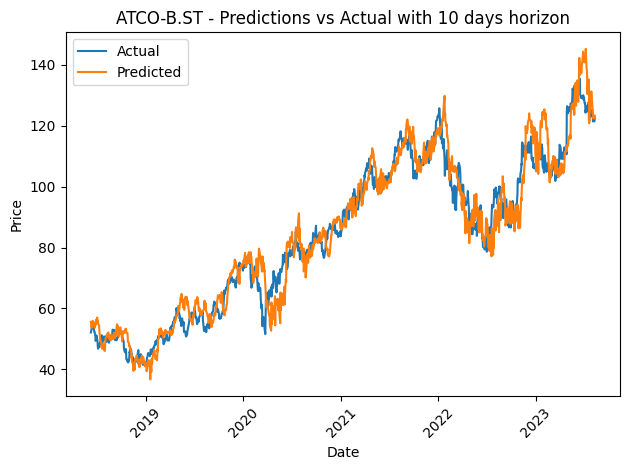

Accuracy: 0.0440
Total accuracy on last horizon: 0.0589
ASSA-B.ST: 0.0434
ATCO-A.ST: 0.0564
ATCO-B.ST: 0.0572
AZN.ST: 0.0435
ELUX-B.ST: 0.0697
ERIC-B.ST: 0.0578
GETI-B.ST: 0.0736
HEXA-B.ST: 0.0536
HM-B.ST: 0.0705
INVE-B.ST: 0.0422
KINV-B.ST: 0.0745
NDA-SE.ST: 0.0561
NIBE-B.ST: 0.0688
SAAB-B.ST: 0.0883
SAND.ST: 0.0583
SCA-B.ST: 0.0513
SEB-A.ST: 0.0552
SHB-A.ST: 0.0516
SKF-B.ST: 0.0672
SWED-A.ST: 0.0583
TEL2-B.ST: 0.0429
VOLV-B.ST: 0.0555
Stock accuracy: 0.0572


In [265]:
idx = 2

plot_predictions(
    idx,
    tickers,
    val_loader.dataset,
    cross_attention_lstm_reg,
    0,
    2000
)

Scaled returns: [0.98747185 0.99304307 0.98641968 0.99003198 0.98624891 0.97265251
 0.96856663 0.96693875 0.96150173 0.95747384]
Weights: [1.5171081e-17 8.3449107e-18 1.8725222e-01 2.8941682e-01 1.8975878e-01
 0.0000000e+00 2.0420974e-18 2.6053270e-02 0.0000000e+00 0.0000000e+00
 1.0181660e-17 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.1128967e-17
 3.0751893e-01 1.2690190e-17 1.2250054e-17 0.0000000e+00 6.9327566e-18
 0.0000000e+00 8.7561559e-18]
Full horizon predictions: tensor([ 295.9882,  174.8436,  152.0264, 1385.3748,  115.4917,   60.8344,
         226.0488,  130.7327,  173.7154,  224.5510,  112.3252,  124.6700,
          67.1337,  155.4026,  209.7779,  148.6371,  133.6048,   97.7489,
         192.8532,  181.6455,   81.9827,  249.7963])
Last know prices: tensor([ 280.5746,  166.7444,  142.9289, 1386.2701,  108.5500,   60.1531,
         222.6485,  119.1435,  165.1971,  227.1922,  107.6500,  125.2761,
          69.1390,  152.8889,  207.0451,  146.8299,  130.1731,   98.2359,
       

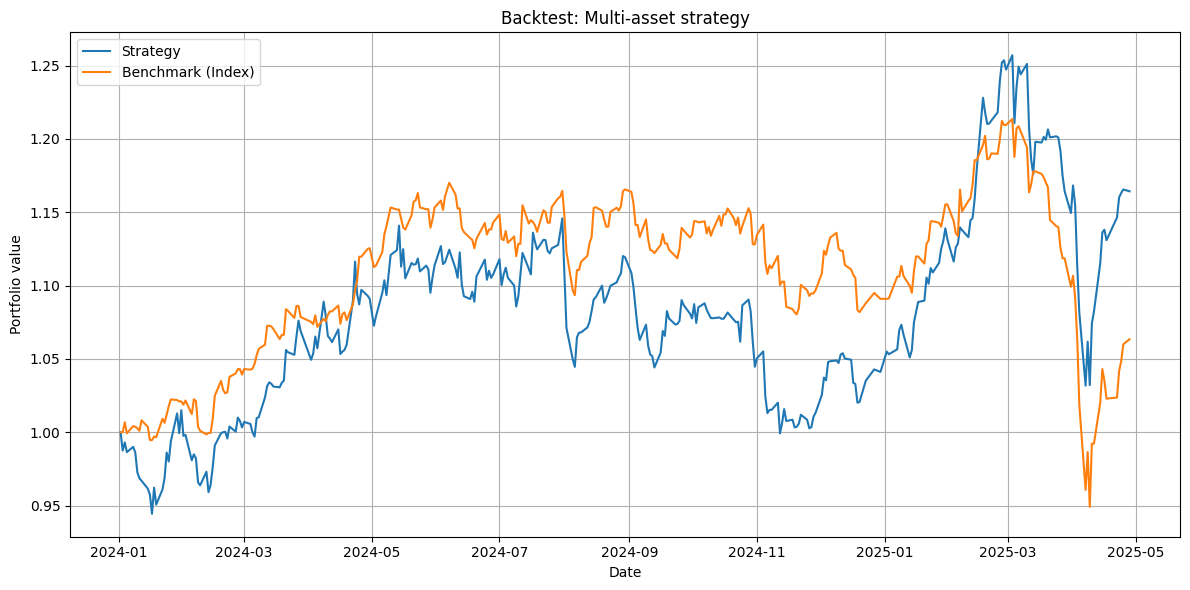

Scaled returns: [1.00097847 0.98947503 0.98958764 0.98911575 1.00429813 1.00502527
 1.00103186 1.00103186 1.00778081 1.01179405]
Weights: [0.00000000e+00 3.26116320e-17 0.00000000e+00 0.00000000e+00
 2.62495428e-02 0.00000000e+00 0.00000000e+00 1.51123002e-01
 3.16431988e-18 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.28491275e-17 0.00000000e+00 0.00000000e+00 1.49697483e-01
 1.11240327e-01 1.78992093e-01 2.30150829e-17 3.82697552e-01
 1.04871156e-16 0.00000000e+00]
Full horizon predictions: tensor([173.2597,  60.7205,  54.2569, 629.1154, 139.3996,  56.6753,  76.9806,
         70.4136, 109.3044,  81.4602, 154.9750,  83.8498,  21.7000,  77.9819,
        133.6021,  95.3308,  65.8823,  73.5418, 146.4064, 122.2855,  71.8075,
        122.0932])
Last know prices: tensor([170.1894,  59.7715,  52.6720, 636.2538, 138.1184,  54.0448,  75.5016,
         67.9118, 104.9022,  80.3905, 154.2000,  82.7769,  21.9520,  79.0990,
        130.6075,  90.7103,  63.7872,  69.9895, 142.5505, 117.1554,  69.

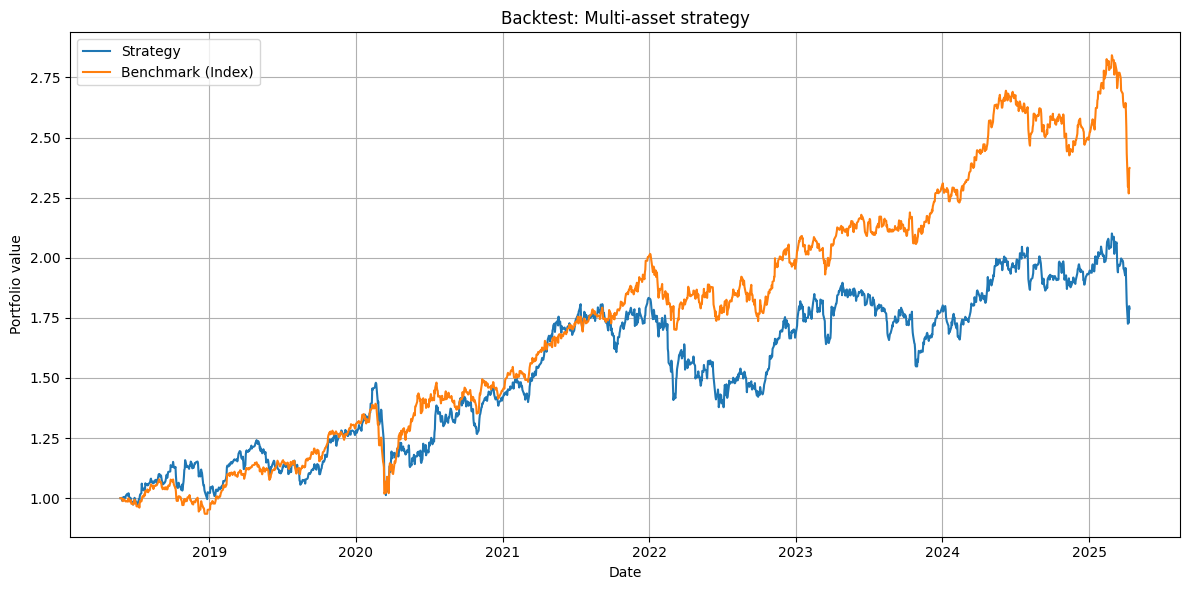

In [275]:
weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=0.5
)

result = backtest_multi_asset(
    ds_test,
    cross_attention_lstm_reg,
    weight_optimizer,
    df_test,
    index_df=df_index,
    plot=True
)
result = backtest_multi_asset(
    ds_val_test,
    cross_attention_lstm_reg,
    weight_optimizer,
    df_val_test,
    index_df=df_index,
    plot=True
)